# The bipolar north fold (on tripolar grids)

The [MOM6 example](03_MOM6.ipynb) ended on an admission. It computed the relative
vorticity $\zeta = \partial v/\partial x - \partial u/\partial y$ of GFDL-CM4's
surface flow, and then said:

> Near the North Pole this crosses the bipolar north **fold**, so for this simple
> global map we just look away from the Arctic seam.

This notebook stops looking away.

Global ocean grids like MOM6, NEMO and Oceananigans are **tripolar**: besides the
ordinary South Pole they carry two more poles, displaced over Arctic land, and the
northern edge of the logical grid folds onto itself along the **bipolar seam**
joining them. That top edge is not a wall. It is glued to *itself*, reversed. A
`diff` that reaches past it needs the cells on the far side of the fold, not a
guess.

xgcm can supply them. Telling the `Grid` that its Y axis ends in a fold —
`padding={"Y": {"fold": "corner"}}` — is the whole fix, and the rest of the code
is unchanged.

In [1]:
import numpy as np
import xarray as xr
import pooch

from xgcm import Grid
from xgcm.padding import pad

# Figure-drawing only; every xgcm call in this notebook stays inline and visible.
import tripolar_plots as tp

so = {"storage_options": {"token": "anon"}}

# Oceananigans/ClimaOcean tripolar surface snapshot, hosted on Zenodo.
# v1 = model-day 10 (DOI 10.5281/zenodo.20950679). To switch to the day-365 v2
# later, bump just these two lines to the new version's URL + md5 hash.
OCEANANIGANS_URL = "https://zenodo.org/records/20950679/files/oceananigans_tripolar.nc"
OCEANANIGANS_MD5 = "md5:5460639792880fa76826430d9290d87a"

## Picking up where `03_MOM6` left off

The same GFDL-CM4 surface velocities, on the same staggered index grid as before:
`uo` on the east face, `vo` on the north face. The only new thing is the `Y`
padding — we build the grid twice, once the naive way and once with the fold, and
compute `03`'s vorticity with each.

One detail matters. We hand each component to `diff` as a **dict**,
`{"X": vo}` rather than bare `vo`. That is how you tell xgcm *"this array is the
X-component of a vector"*. Folding the grid rotates the local axes by 180°, so a
velocity component reverses sign across the seam while a scalar does not — and
xgcm can only apply that flip if it knows which component it is holding.

In [2]:
base = ("gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/"
        "r1i1p1f1/Omon/{var}/gn/v20180701/")


def surface(var):
    d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
    return d[var].isel(time=0, lev=0)


uo, vo = surface("uo"), surface("vo")
lon, lat = uo["lon"].values, uo["lat"].values
ny, nx = uo.shape

mom6 = xr.Dataset(
    dict(uo=xr.DataArray(uo.values, dims=["y_c", "x_f"]),
         vo=xr.DataArray(vo.values, dims=["y_f", "x_c"])),
    coords=dict(x_c=np.arange(nx), x_f=np.arange(nx),
                y_c=np.arange(ny), y_f=np.arange(ny)),
)


def mom6_vorticity(y_padding):
    """03_MOM6's relative vorticity, with a choice of northern boundary."""
    g = Grid(mom6,
             coords={"X": {"center": "x_c", "right": "x_f"},
                     "Y": {"center": "y_c", "right": "y_f"}},
             padding={"X": "periodic", "Y": y_padding},
             autoparse_metadata=False)
    return (g.diff({"X": mom6.vo}, "X") - g.diff({"Y": mom6.uo}, "Y")).values


zeta_naive = mom6_vorticity("extend")             # what 03_MOM6 did
zeta_fold = mom6_vorticity({"fold": "corner"})    # what MOM6's grid actually does

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(


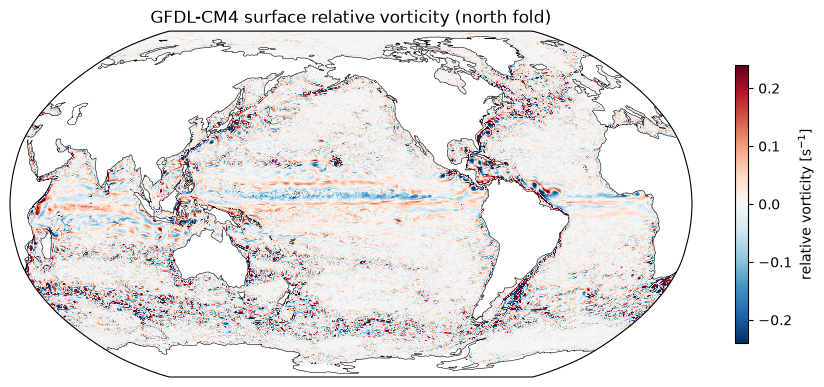

In [3]:
tp.global_vorticity(lon, lat, zeta_fold,
                    title="GFDL-CM4 surface relative vorticity (north fold)")

Same figure as `03_MOM6`: same Robinson projection, same `RdBu_r`, same scale. The
only thing that changed is one keyword — and at this zoom you cannot tell. That is
the honest situation. The fold corrects the **seam row and nothing else**, so out
of 1080 rows exactly one moves, and it is a hairline near the pole, drawn over
Arctic land, an order of magnitude below the coastal vorticity that sets the colour
scale.

So a map is the wrong instrument for looking at this, and the rest of the notebook
does not use one. To see what the fold actually did we have to go to the seam and
zoom in — which, conveniently, is also where the tripolar grid is easiest to
understand: in **logical index space**, where the fold is just the top row of an
array.

Two things are worth holding onto from the figure above, though. The fix was
`padding={"Y": {"fold": "corner"}}` and nothing else; and every value below the
seam is bit-for-bit what `03` already had. The fold is not a different way of
computing vorticity. It is the correct neighbourhood at one edge.

## Models fold in different places

`"corner"` above was not a magic word. It names the **pivot**: which sublattice the
two northern poles sit on. Models differ here, and getting it wrong misaligns the
reflection by half a cell.

The four conventions, in the usual ocean-model T/U/V/F shorthand:

| pivot | poles sit on | used by |
|---|---|---|
| `"center"` / `"t"` | a tracer (T) point | some MOM5 configurations |
| `"corner"` / `"f"` | a cell corner (F) point | MOM6, NEMO |
| `"u"` | a U (east/west face) point | Oceananigans |
| `"v"` | a V (north/south face) point | — |

See the [grid topology docs](../grid_topology.md#north-fold) for how each pivot maps
onto the halo, and how xgcm infers the seam (zonal) axis from the periodic one.

To show this is not a MOM6 quirk, the rest of the notebook carries **three** real
models with two different pivots: MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from
CMIP6, both `"corner"`, plus an Oceananigans/ClimaOcean 1° snapshot with a `"u"`
pivot.

In [4]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label,
                ny=ny, nx=nx)


def _grid(coords, edge, ybc):
    '''A Grid on this model's index coords: the seam axis X wraps, and the fold
    axis Y carries either the north-fold spec or a naive boundary (for contrast).'''
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                padding={"X": "periodic", "Y": ybc},
                # these are bare index coordinates, with no Comodo/SGRID attributes
                # for xgcm to parse, so we describe the positions ourselves above
                autoparse_metadata=False)


def speed_centre(m):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    uc = g.interp(m["u"], "X")
    vc = g.interp({"Y": m["v"]}, "Y")
    return np.hypot(uc, vc)


def divergence(m):
    '''Horizontal divergence du/dx + dv/dy at the cell centre; the dv/dy term
    crosses the fold, so this exercises `diff` (and the vector fold of v) across
    the seam. Unlike vorticity, divergence is a TRUE SCALAR — invariant under the
    180 degree fold — so it is continuous across the seam and its halo is simply
    the mirrored interior, with no sign subtlety.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    dudx = g.diff(m["u"], "X")  # X is periodic (the seam axis); let it wrap
    dvdy = g.diff({"Y": m["v"]}, "Y")
    return dudx + dvdy


def fill_seam_vrow(m):
    '''Reconstruct the redundant top row of the meridional velocity ``v``.

    On a tripolar F-fold the top ``v`` faces lie on the seam and come in fold
    pairs ``v(i) = -v(mirror(i))``; the CMIP6 NEMO/MOM6 products keep one half of
    that row and mask the other (the redundant duplicate). xgcm's fold fills
    *halos* from the interior, not interior gaps, so we rebuild this seam row
    here from its fold partner. Without it, interpolating ``v`` to the cell
    centre (e.g. for surface speed) would leave a blank band at the seam. Only
    masked cells whose fold partner is present are filled (a no-op for fields
    that are already complete, e.g. the Oceananigans simulation output).'''
    v = np.asarray(m["v"].values).copy()
    nx = v.shape[1]
    mirror = (-np.arange(nx) - 1) % nx          # seam reflection (seam axis = edge)
    top = v[-1]
    fill = ~np.isfinite(top) & np.isfinite(top[mirror])
    top[fill] = -top[mirror][fill]              # v flips sign across the fold
    m["v"] = m["v"].copy(data=v)

In [5]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    b = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
         f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(b.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(b.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    path = pooch.retrieve(url=OCEANANIGANS_URL, known_hash=OCEANANIGANS_MD5,
                          fname="oceananigans_tripolar.nc")
    o = xr.open_dataset(path)
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]
for m in models:          # F-pivot models ship the redundant top v-row masked; rebuild it
    if m["fold"] in ("corner", "f"):
        fill_seam_vrow(m)

### The arrays, as they sit in memory

Before any fold machinery: each model's surface speed in raw grid-index space —
y-index up, x-index across, no projection. The red line is the top edge of the
array, the one that is glued to itself.

For the rest of the notebook we look at the fold **here**, in index space, rather
than on a map. On a polar projection the seam is distorted, split by land, and
easy to mistake for a rendering artifact. In index space it is just a horizontal
line, and what the fold does to it is unambiguous.

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. It

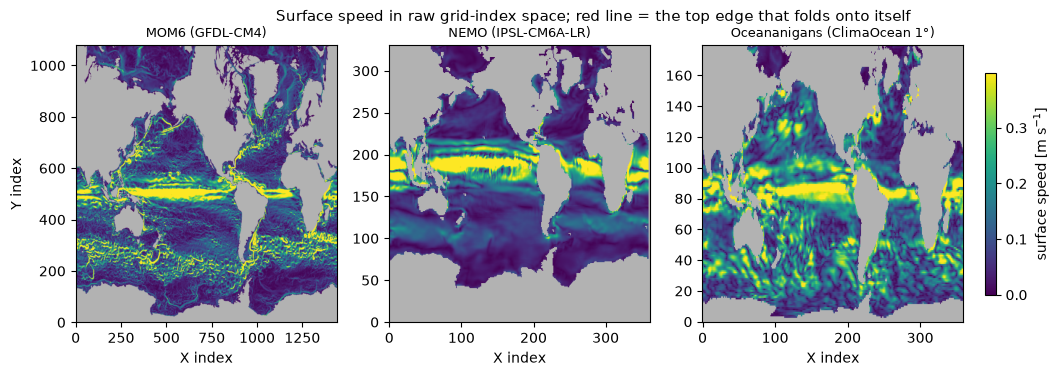

In [6]:
for m in models:
    m["speed"] = speed_centre(m)      # `interp` crosses the fold

tp.index_space_overview(models)

## Under the hood: `pad`

`interp` and `diff` pad for you — that is why the fix at the top of this notebook
was a single keyword. But to *see* what they padded with, we can step underneath
them and call `xgcm.padding.pad` directly.

This is not how you would normally use xgcm, and `pad` is not part of the public
API documented in [the API reference](../api.md). We reach for it here only
because it hands back exactly the halo the operators build internally, so we can
plot a fold halo and a naive halo side by side and compare them cell by cell.

`padding_width={"Y": (0, K)}` asks for `K` extra rows above the top of the array.

In [7]:
def _pad_scalar(S, m, K, mode):
    '''K halo rows above a centre scalar field: fold (mirror) or extend (smear).'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if mode == "fold" else "extend")
    return np.asarray(pad(S, g, padding_width={"Y": (0, K)}).values)


def _pad_v(m, K, mode, vector):
    '''K halo rows above the v component. vector=True folds it as a vector (the
    180 degree pivot flips its sign); vector=False folds it as a plain scalar. v
    lives at (y_f, x_c); for the vector case u is the other (X) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"Y": m["v"]}, g, padding_width={"Y": (0, K)}, other_component={"X": m["u"]})
    else:
        out = pad(m["v"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


def _pad_u(m, K, mode, vector):
    '''K halo rows above the u component (zonal), as above. u lives at (y_c, x_f);
    for the vector case v is the other (Y) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"X": m["u"]}, g, padding_width={"Y": (0, K)}, other_component={"Y": m["v"]})
    else:
        out = pad(m["u"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


# Everything the figures below draw is computed here, with xgcm, so the operators
# stay in plain sight: the diagnostics, then their halos filled both ways.
K = 6
for m in models:
    m["div"] = divergence(m)                            # `diff` crosses the fold
    for name in ("speed", "div"):
        m[f"{name}_fold"] = _pad_scalar(m[name], m, K, "fold")
        m[f"{name}_naive"] = _pad_scalar(m[name], m, K, "extend")
    for comp, pad_fn in (("v", _pad_v), ("u", _pad_u)):
        m[f"{comp}_scalarfold"] = pad_fn(m, K, "fold", False)
        m[f"{comp}_vectorfold"] = pad_fn(m, K, "fold", True)

tp.attach_windows(models, K=K)   # one shared open-water window per model, for every figure below

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. It

### `interp` across the fold — what fills the halo

Surface speed at tracer points near the seam, zoomed to a patch of open water so
each grid cell is visible. Below the black line is the real interior. Above it is
halo — invented by whichever boundary condition we chose.

The **fold halo** is the genuine cross-seam neighbourhood: the interior reflected
about the pole, structured, continuing the field. The **naive** halo copies the
edge value straight up, so every column is a constant vertical streak. Their
**difference** is zero below the line and nonzero only above it.

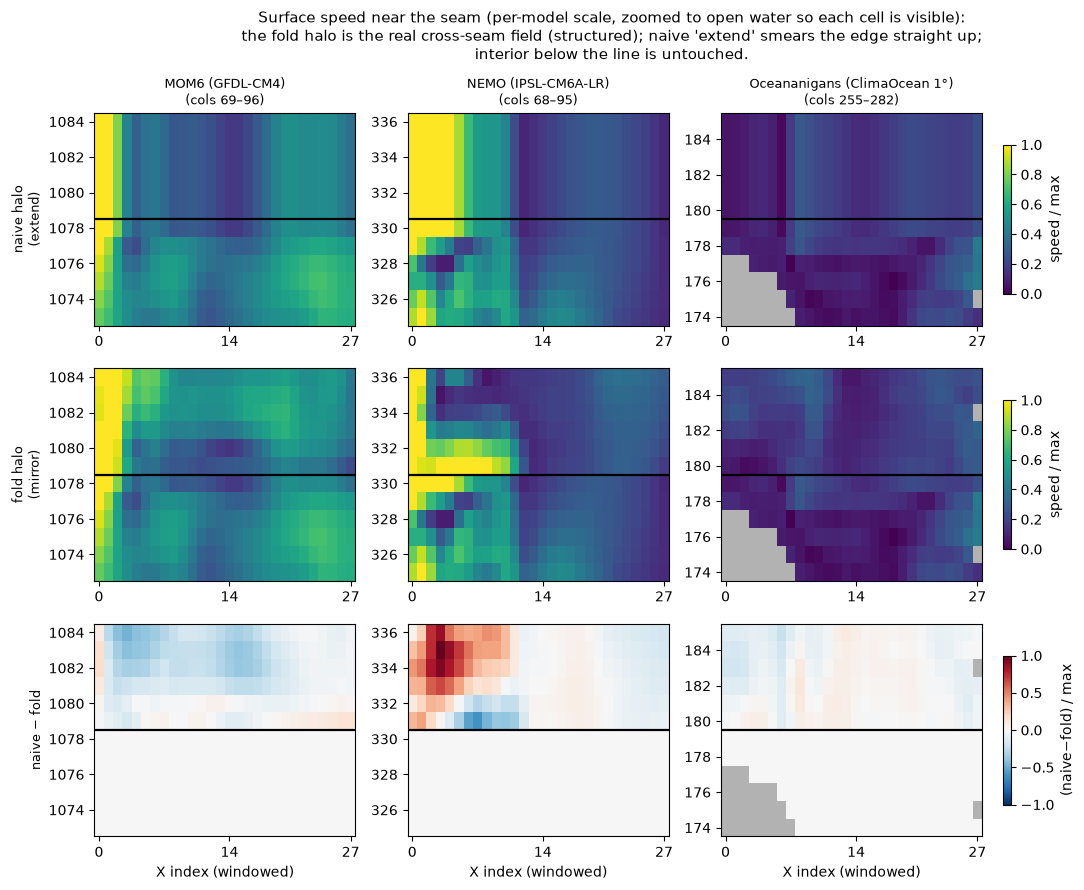

In [8]:
tp.halo_strip(models, "speed_naive", "speed_fold", K=K,
              cbar_label="speed / max",
              suptitle="Surface speed near the seam (per-model scale, zoomed to open water so each "
                       "cell is visible):\nthe fold halo is the real cross-seam field (structured); "
                       "naive 'extend' smears the edge straight up;\ninterior below the line is "
                       "untouched.")

### Why the vector dict matters

This is the sign flip that the `{"X": vo}` dict at the top of the notebook bought
us. Each component is folded twice in the same window: once as a plain **scalar**,
once **as a vector** (passing its partner via `other_component`).

Below the seam the two are identical. In the **halo** they are the same magnitude
with **opposite sign** — the colours invert — for `u` and `v` alike. That flip is
the 180° pivot. Hand xgcm a bare array and it cannot know to do this.

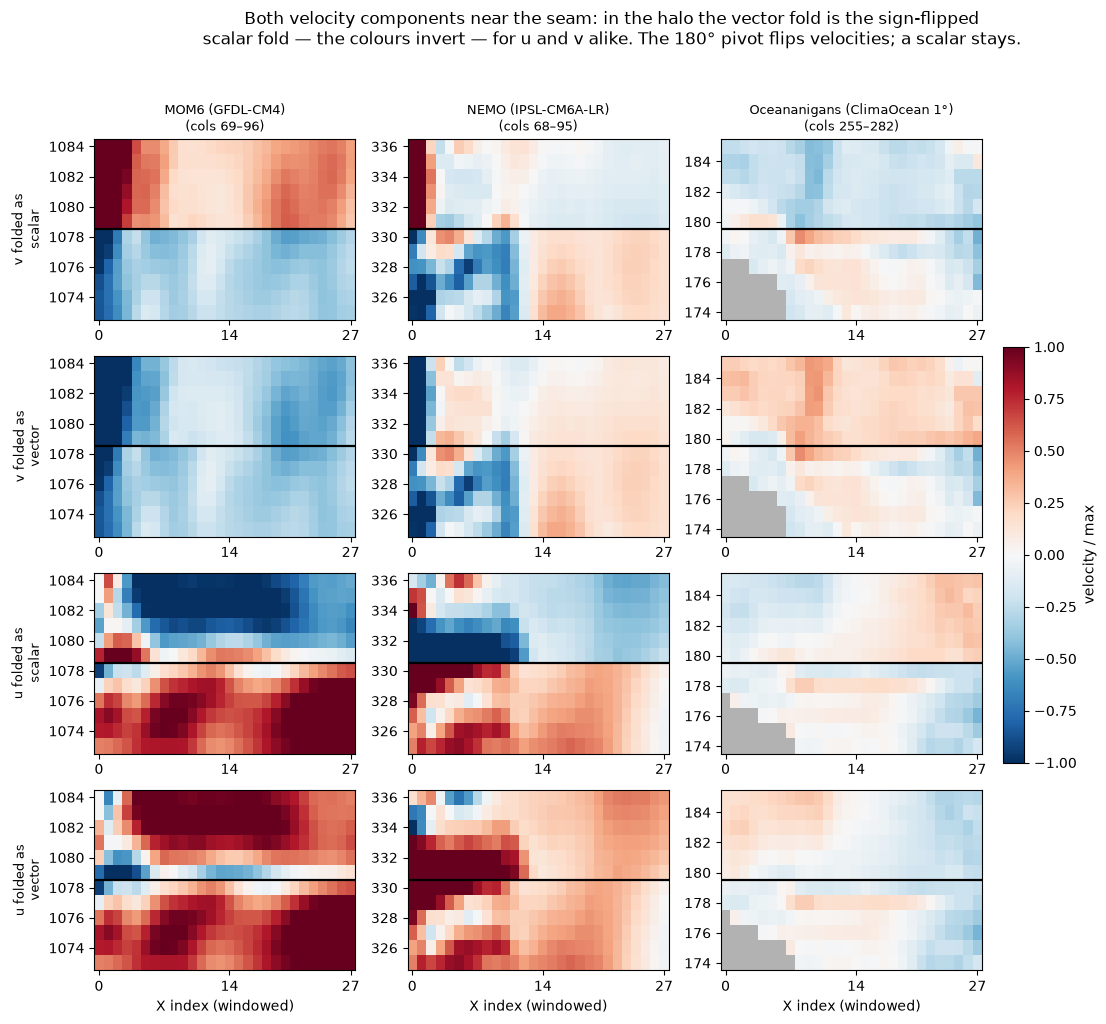

In [9]:
tp.component_strip(models, K=K)

### Continuity across the seam

The cleanest check. Follow a few ocean columns from the interior, across the seam
(dotted), into the halo. The **fold** continues the real, varying field, because
the seam partner is a genuine physical neighbour. The **naive** boundary flatlines
at the edge value. Where a column runs into Arctic land the line simply stops —
that is land, not a fold error.

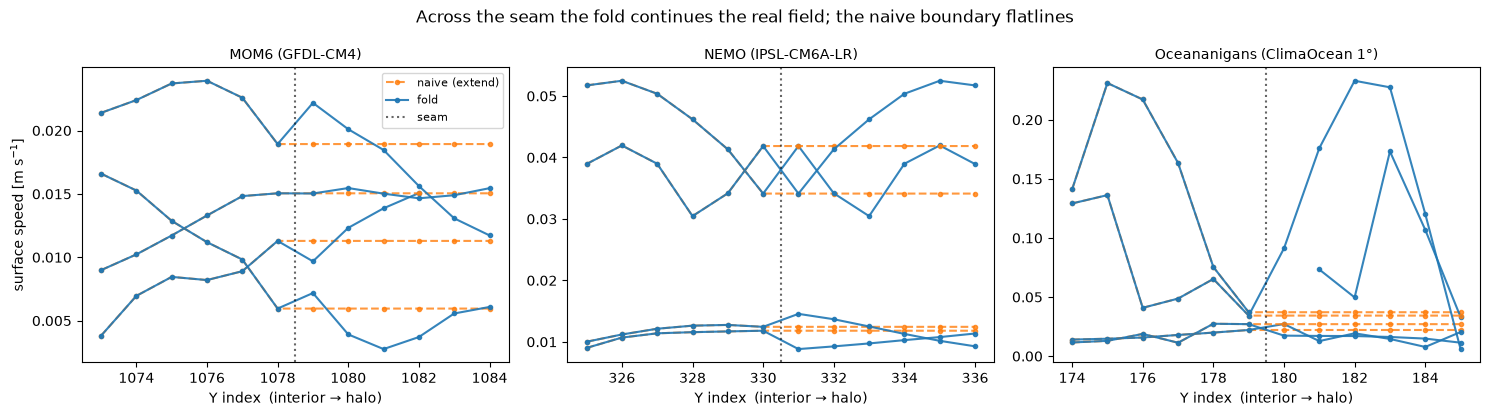

In [10]:
tp.seam_transect(models, K=K)

### `diff` across the fold

The opening figure used `diff` for vorticity. Here it is again on all three models,
via the horizontal divergence $\nabla\!\cdot\mathbf{u} = \partial u/\partial x +
\partial v/\partial y$, whose $\partial v/\partial y$ term crosses the seam.

Divergence is chosen deliberately: it is a **true scalar**, invariant under the
fold's 180° rotation. Vorticity — the pseudoscalar we opened with — flips sign
across the fold and lives at the awkward cell corner, which is exactly what makes
it a good *demonstration* and a poor *diagnostic*. Divergence has no sign subtlety,
so its fold halo is simply the mirrored interior.

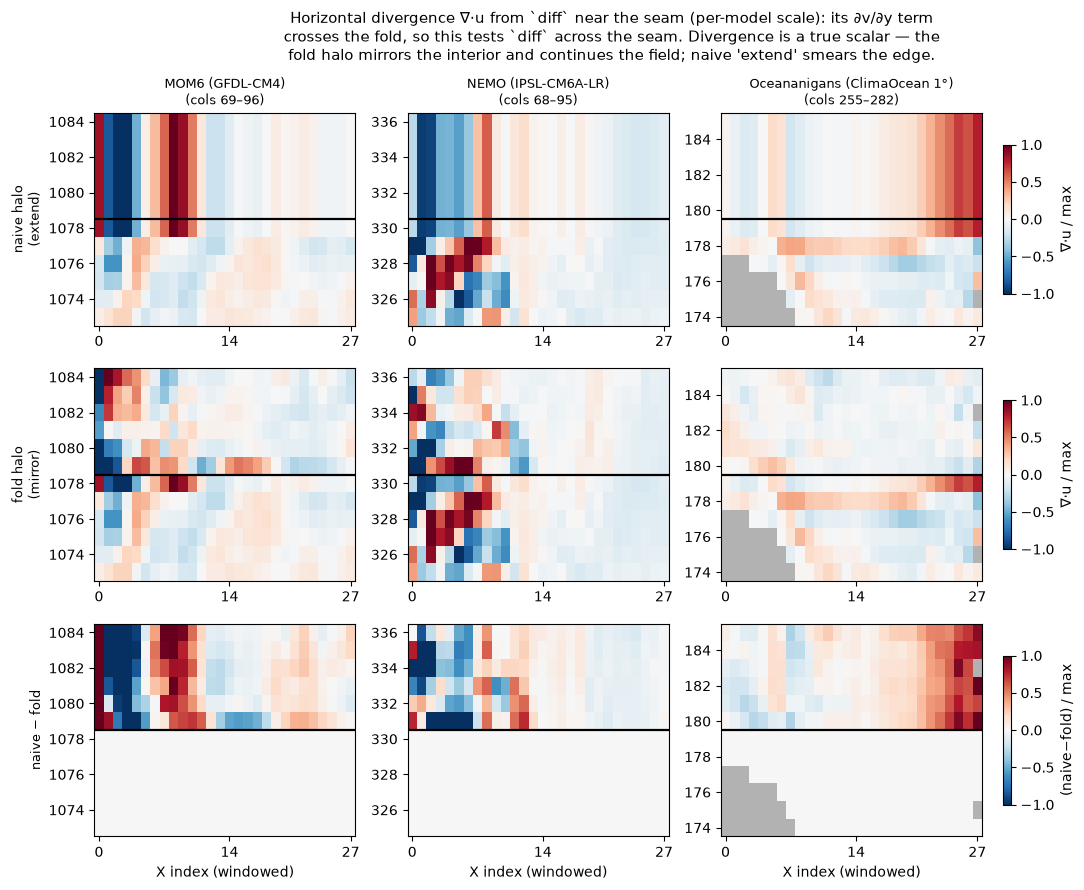

In [11]:
tp.halo_strip(models, "div_naive", "div_fold", K=K, signed=True,
              cbar_label="∇·u / max",
              suptitle="Horizontal divergence ∇·u from `diff` near the seam (per-model scale): its "
                       "∂v/∂y term\ncrosses the fold, so this tests `diff` across the seam. "
                       "Divergence is a true scalar — the\nfold halo mirrors the interior and "
                       "continues the field; naive 'extend' smears the edge.")

## Takeaway

The fix was one keyword. Setting
`padding={"X": "periodic", "Y": {"fold": ...}}` makes the ordinary staggered
`interp`/`diff`/`derivative` work across the pole, for all three models'
conventions — `"corner"` for MOM6 and NEMO, `"u"` for Oceananigans. Nothing else
in `03_MOM6`'s vorticity calculation had to change.

What the fold does, seen directly in index space:

* it fills the northern halo with the **interior reflected about the poles**, so a
  smooth scalar (surface speed) **continues across the seam** while a naive
  `extend` boundary smears the edge and flatlines;
* it **reverses the sign** of vector components — the signature of the 180° pivot —
  provided you hand it the component as a `{axis: array}` dict so it knows what it
  is holding;
* it leaves the interior **untouched**, correcting only the seam row.

Because the halo is provably the reflected interior, structure at the seam is the
model's own field mirrored, not an artifact. The mirror symmetry is the tell — the
grid-scale noise in the coarse, short-spin-up Oceananigans field mirrors just as
faithfully as the smooth CMIP6 fields do.

Further reading: the [grid topology docs](../grid_topology.md#north-fold) for the
four pivots and how the halo is filled, and [`03_MOM6.ipynb`](03_MOM6.ipynb) for
more MOM6 recipes.